In [20]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split


In [22]:
data = pd.read_csv("letter-recognition.data", header=None)
data

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,D,2,2,3,3,2,7,7,7,6,6,6,4,2,8,3,7
19996,C,7,10,8,8,4,4,8,6,9,12,9,13,2,9,3,7
19997,T,6,9,6,7,5,6,11,3,7,11,9,5,2,12,2,4
19998,S,2,3,4,2,1,8,7,2,6,10,6,8,1,9,5,8


In [24]:
# Split features and labels
X = data.iloc[:, 1:].values   # 16 features
y = data.iloc[:, 0].values    # letters
print(X)
print(y)

[[ 2  8  3 ...  8  0  8]
 [ 5 12  3 ...  8  4 10]
 [ 4 11  6 ...  7  3  9]
 ...
 [ 6  9  6 ... 12  2  4]
 [ 2  3  4 ...  9  5  8]
 [ 4  9  6 ...  7  2  8]]
['T' 'I' 'D' ... 'T' 'S' 'A']


In [26]:
# Encode labels
le = LabelEncoder()
y = le.fit_transform(y)

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)
X

array([[-1.0576983 ,  0.29187713, -1.05327668, ..., -0.21908163,
        -1.4381527 ,  0.12291107],
       [ 0.51038497,  1.5023577 , -1.05327668, ..., -0.21908163,
         0.12008142,  1.35944092],
       [-0.01230945,  1.19973756,  0.43590966, ..., -0.8656262 ,
        -0.26947711,  0.74117599],
       ...,
       [ 1.03307939,  0.59449727,  0.43590966, ...,  2.36709667,
        -0.65903564, -2.35014863],
       [-1.0576983 , -1.22122359, -0.55688123, ...,  0.42746295,
         0.50963994,  0.12291107],
       [-0.01230945,  0.59449727,  0.43590966, ..., -0.8656262 ,
        -0.65903564,  0.12291107]])

In [28]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [32]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(16,)),
    Dense(64, activation='relu'),
    Dense(26, activation='softmax')   # 26 classes
])

C:\Users\Varad\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [36]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5706 - loss: 1.6215 - val_accuracy: 0.7394 - val_loss: 0.9181
Epoch 2/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7793 - loss: 0.7660 - val_accuracy: 0.8037 - val_loss: 0.6517
Epoch 3/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8287 - loss: 0.5885 - val_accuracy: 0.8400 - val_loss: 0.5306
Epoch 4/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8581 - loss: 0.4879 - val_accuracy: 0.8600 - val_loss: 0.4543
Epoch 5/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8767 - loss: 0.4187 - val_accuracy: 0.8819 - val_loss: 0.3999
Epoch 6/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8914 - loss: 0.3683 - val_accuracy: 0.8950 - val_loss: 0.3523
Epoch 7/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9026 - loss: 0.3284 - val_accuracy: 0.9013 - val_loss: 0.3209
Epoch 8/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9103 - loss: 0.2955 - val_accuracy: 0.

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

MODEL EVALUATION METRICS
Accuracy  : 0.9463
Precision : 0.9477
Recall    : 0.9463
F1-Score  : 0.9464

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       149
           1       0.92      0.93      0.93       153
           2       0.96      0.92      0.94       137
           3       0.94      0.95      0.95       156
           4       0.82      0.96      0.89       141
           5       0.92      0.90      0.91       140
           6       0.93      0.97      0.95       160
           7       0.87      0.90      0.88       144
           8       0.99      0.91      0.95       146
           9       0.92      0.98      0.95       149
          10       0.92      0.93      0.93       130
          11       0.96      0.97      0.96       155
          12       0.96      0.98      0.97       168
          13       0.99      0.93      0.96       151
          14       0.95

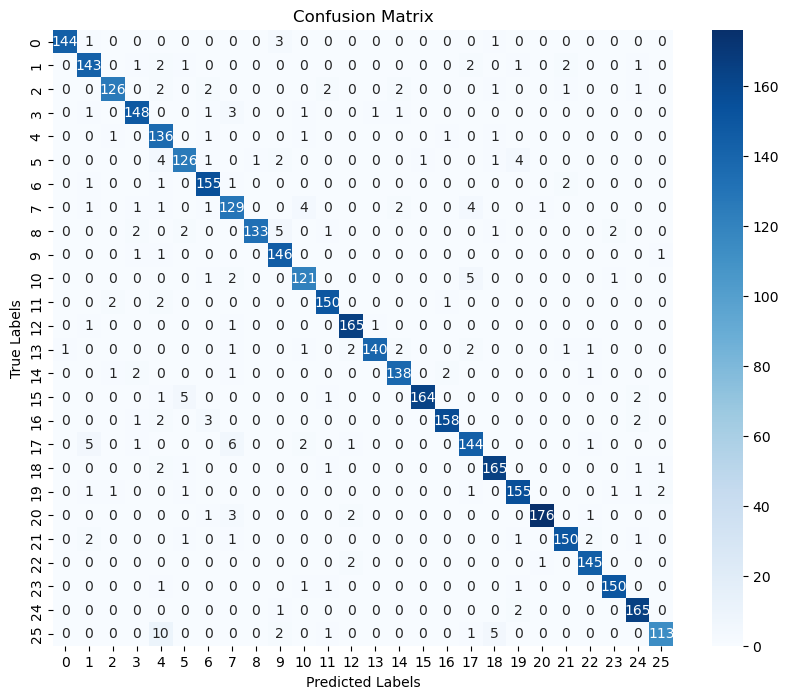

In [38]:
# ============================================================
# EVALUATION METRICS FOR MULTICLASS CLASSIFICATION
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# PREDICT TEST DATA
# ------------------------------------------------------------

y_pred_probs = model.predict(X_test)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# If y_test is one-hot encoded
if len(y_test.shape) > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

# ------------------------------------------------------------
# CALCULATE METRICS
# ------------------------------------------------------------

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

# ------------------------------------------------------------
# PRINT METRICS
# ------------------------------------------------------------

print("\n================================================")
print("MODEL EVALUATION METRICS")
print("================================================")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

# ------------------------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n================================================")
print("CLASSIFICATION REPORT")
print("================================================")

print(classification_report(y_true, y_pred))

# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

plt.show()

In [40]:
import numpy as np

sample = X_test[0].reshape(1, -1)
prediction = model.predict(sample)

predicted_letter = le.inverse_transform([np.argmax(prediction)])
print("Predicted:", predicted_letter)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
Predicted: ['X']
